<a href="https://colab.research.google.com/github/isadorapandas/data-science-series-temporais/blob/main/Series_temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Vamos analisar os dados sobre uma empresa de bicicletas
# para obter insights e ajudar a otimizar ainda mais o seu serviço.
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/isadorapandas/data-science-series-temporais/refs/heads/main/bicicletas.csv")

In [2]:
df.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [3]:
# checando a dimensão do conjunto de dados
df.shape

(17429, 10)

In [4]:
# para saber mais detalhes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17429 entries, 0 to 17428
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17429 non-null  object 
 1   contagem          17429 non-null  int64  
 2   temperatura       17406 non-null  float64
 3   sensacao_termica  17406 non-null  float64
 4   umidade           17429 non-null  float64
 5   velocidade_vento  17429 non-null  float64
 6   clima             17429 non-null  object 
 7   feriado           17429 non-null  object 
 8   fim_de_semana     17429 non-null  object 
 9   estacao           17429 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.3+ MB


In [5]:
# verificando qts nulos há
df.isnull().sum()

,0
data_hora,0
contagem,0
temperatura,23
sensacao_termica,23
umidade,0
velocidade_vento,0
clima,0
feriado,0
fim_de_semana,0
estacao,0


In [6]:
# Dentre as alternativas para tratar dados nulos, a forma mais radical de
# tratamento é o dropna(), que simplesmente exclui a linha inteira que contém
# uma informação nula.
# Além disso, existem algumas formas de preencher esses valores, ao invés
# de simplesmente excluí-los. Poderíamos usar o ffill(), que preenche usando
# o valor anterior.
# Vamos usar uma estratégia bem interessante com ajuda do método
# interpolate() para interpolar valores

In [7]:
df['temperatura'] = df['temperatura'].interpolate(method='linear')
df['sensacao_termica'] = df['sensacao_termica'].interpolate(method='linear')

In [8]:
df.head(10)

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno
5,2015-01-04 05:00:00,46,2.00,2.00,93.0,4.0,Céu limpo,Não,Sim,Inverno
6,2015-01-04 06:00:00,51,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
7,2015-01-04 07:00:00,75,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
8,2015-01-04 08:00:00,131,1.50,-1.00,96.5,8.0,Parcialmente nublado,Não,Sim,Inverno
9,2015-01-04 09:00:00,301,2.00,-0.50,100.0,9.0,Nublado,Não,Sim,Inverno


In [9]:
# verificando informações duplicadas
df.duplicated().sum()

np.int64(15)

In [10]:
# descobrindo quais são
df.duplicated(keep=False)

,0
0,False
1,False
2,False
3,False
4,False
...,...
17424,True
17425,True
17426,True
17427,True


In [11]:
duplicatas = df.duplicated(keep=False)
linhas_duplicadas = df[duplicatas]
linhas_duplicadas

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
5360,2015-08-15 23:00:00,759,17.0,17.0,59.0,6.0,Céu limpo,Não,Sim,Verão
8174,2015-12-12 11:00:00,1100,12.0,12.0,82.0,20.0,Chuva leve,Não,Sim,Inverno
8175,2015-12-12 12:00:00,1308,13.0,13.0,77.0,26.0,Chuva leve,Não,Sim,Inverno
8528,2015-12-27 05:00:00,57,15.0,15.0,72.0,31.0,Parcialmente nublado,Não,Sim,Inverno
9428,2016-02-02 17:00:00,2846,8.0,4.5,59.5,23.0,Parcialmente nublado,Não,Não,Inverno


In [12]:
# ordenando por data
linhas_duplicadas.sort_values(by='data_hora')

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
17422,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
17417,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
17425,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
17421,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
17418,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão


In [13]:
# removedno duplicatas
df_limpo = df.drop_duplicates()
df_limpo.shape

(17414, 10)

In [14]:
# atividade: realizando o carregamento e processamento dos dados
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/data_science_projeto/main/Dados/bicicletas.csv')

df.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [15]:
df.columns

Index(['data_hora', 'contagem', 'temperatura', 'sensacao_termica', 'umidade',
       'velocidade_vento', 'clima', 'feriado', 'fim_de_semana', 'estacao'],
      dtype='object')

In [16]:
df.shape

(17429, 10)

In [17]:
# verificando a quantidade total de valores, identificamos 23 valores nulos nas colunas temperatura e sensacao_termica
# vamos substituir os valores da temperatura pela média entre o valor anterior e o valor posterior

df['temperatura'] = df['temperatura'].interpolate(method='linear')
df['sensacao_termica'] = df['sensacao_termica'].interpolate(method='linear')

In [18]:
# identificamos 15 valores duplicados

# Identificando as linhas duplicadas no DataFrame
duplicatas = df.duplicated(keep=False)

# Selecionando as linhas duplicadas com base no resultado anterior
linhas_duplicadas = df[duplicatas]

# Ordenando as linhas duplicadas pela coluna 'data_hora'
linhas_duplicadas.sort_values(by='data_hora')

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
17422,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
17417,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
17425,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
17421,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
17418,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão


In [19]:
# Como os dados foram coletados de hora em hora não é esperado que eles
# sejam completamente iguais, incluindo o horário. Portanto, consideramos
# que esses dados não deveriam estar duplicados e iremos excluí-los
df_limpo = df.drop_duplicates()
df_limpo

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno
...,...,...,...,...,...,...,...,...,...,...
17409,2017-01-03 19:00:00,1042,5.00,1.00,81.0,19.0,Nublado,Não,Não,Inverno
17410,2017-01-03 20:00:00,541,5.00,1.00,81.0,21.0,Parcialmente nublado,Não,Não,Inverno
17411,2017-01-03 21:00:00,337,5.50,1.50,78.5,24.0,Parcialmente nublado,Não,Não,Inverno
17412,2017-01-03 22:00:00,224,5.50,1.50,76.0,23.0,Parcialmente nublado,Não,Não,Inverno


In [20]:
df_limpo.describe()

,contagem,temperatura,sensacao_termica,umidade,velocidade_vento
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468206,11.521080,72.324954,15.913063
std,1085.108068,5.571670,6.614799,14.313186,7.894570
min,0.000000,-1.500000,-6.000000,20.500000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000
max,7860.000000,34.000000,34.000000,100.000000,56.500000


In [21]:
# analisando as distribuições
import seaborn as sns
import matplotlib.pyplot as plt

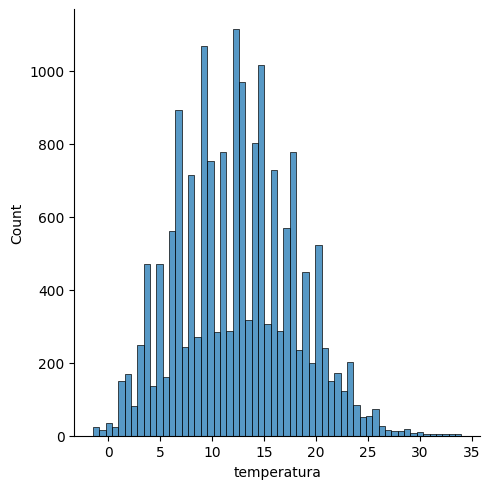

In [22]:
# histograma da temperatura
sns.displot(df_limpo, x='temperatura')
plt.show()

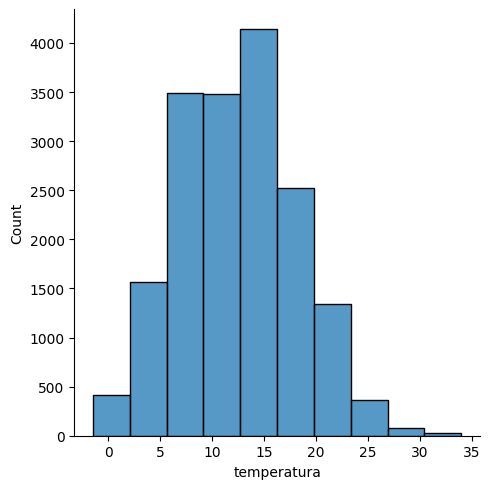

In [23]:
sns.displot(df_limpo, x='temperatura', bins=10)
plt.show()

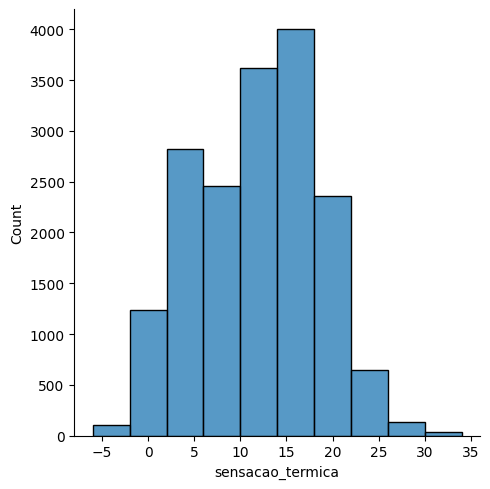

In [24]:
# histograma da sensação térmica
sns.displot(df_limpo, x='sensacao_termica', bins=10)
plt.show()

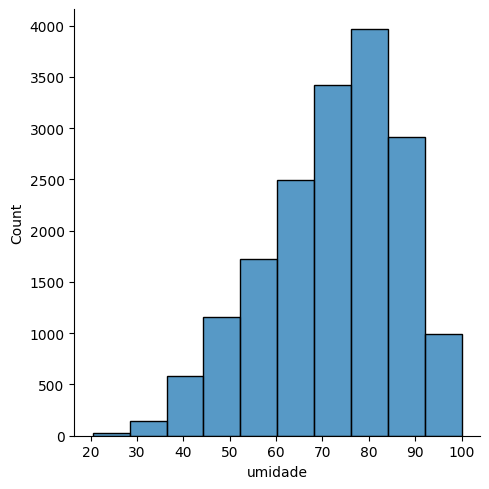

In [25]:
# histograma da umidade
sns.displot(df_limpo, x='umidade', bins=10)
plt.show()

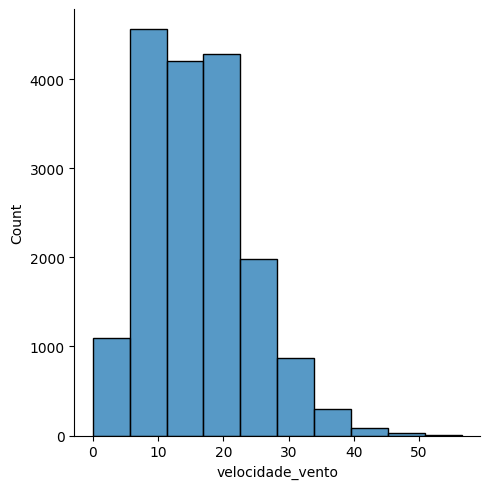

In [26]:
# histograma da velocidade do vento
sns.displot(df_limpo, x='velocidade_vento', bins=10)
plt.show()

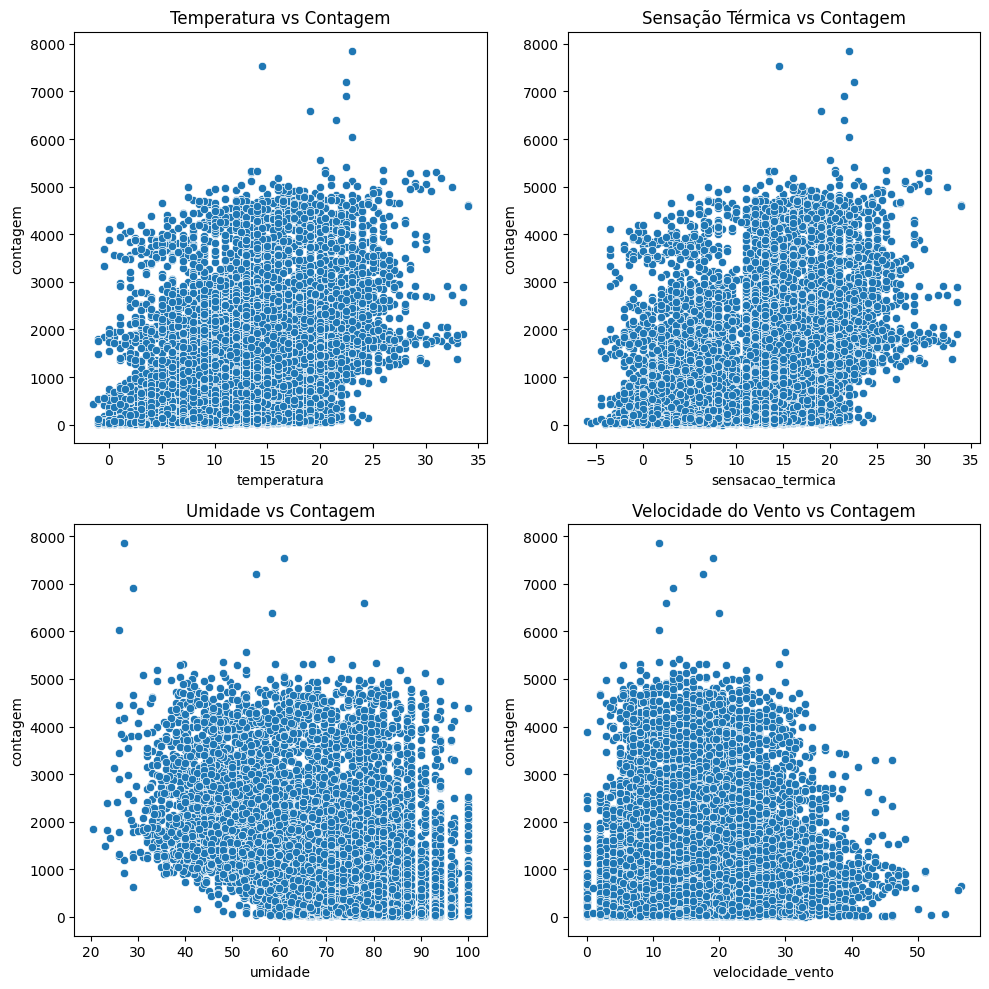

In [27]:
# relação entre variáveis

import matplotlib.pyplot as plt
# Create a figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Plot 1: Temperatura vs Contagem
sns.scatterplot(data=df_limpo, x='temperatura', y='contagem', ax=axes[0, 0])
axes[0, 0].set_title('Temperatura vs Contagem')

# Plot 2: Sensação Térmica vs Contagem
sns.scatterplot(data=df_limpo, x='sensacao_termica', y='contagem', ax=axes[0, 1])
axes[0, 1].set_title('Sensação Térmica vs Contagem')

# Plot 3: Umidade vs Contagem
sns.scatterplot(data=df_limpo, x='umidade', y='contagem', ax=axes[1, 0])
axes[1, 0].set_title('Umidade vs Contagem')

# Plot 4: Velocidade do Vento vs Contagem
sns.scatterplot(data=df_limpo, x='velocidade_vento', y='contagem', ax=axes[1, 1])
axes[1, 1].set_title('Velocidade do Vento vs Contagem')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

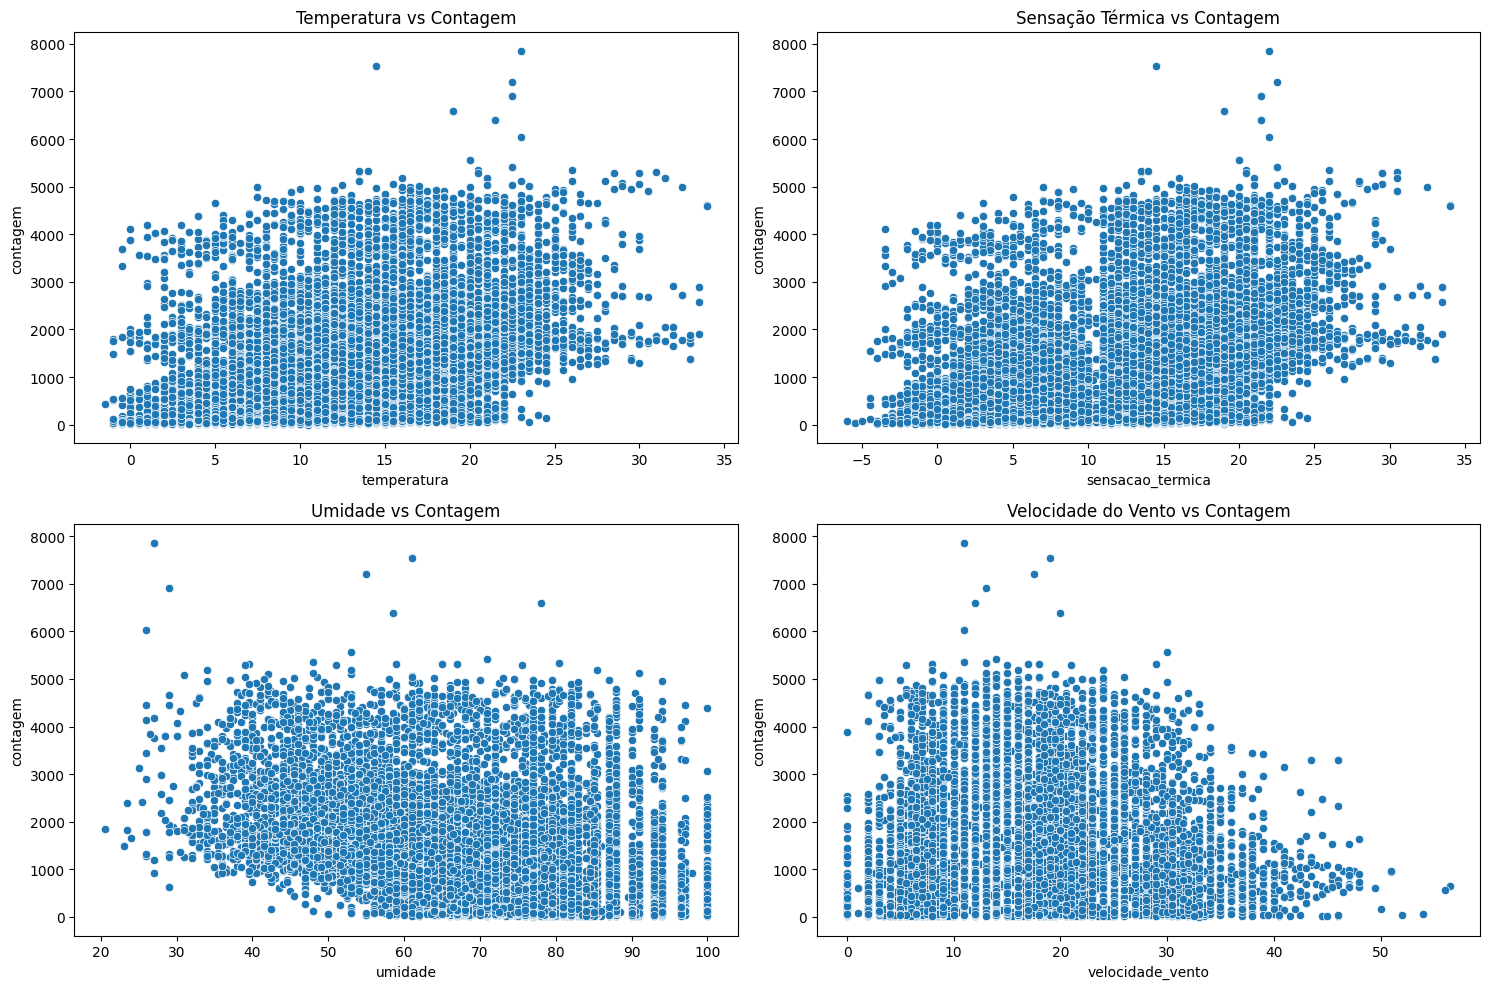

In [28]:
# prompt: crie 4 gráficos do tipo scatterplot das variáveis temperatura, sensacao_termica, umidade, velocidade_vento com a coluna contagem no eixo y. deixar os gráficos na posição 2X2. Cada gráfico deve ter um título.

# Create a figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot the scatterplots
sns.scatterplot(ax=axes[0, 0], data=df_limpo, x='temperatura', y='contagem')
axes[0, 0].set_title('Temperatura vs Contagem')
sns.scatterplot(ax=axes[0, 1], data=df_limpo, x='sensacao_termica', y='contagem')
axes[0, 1].set_title('Sensação Térmica vs Contagem')
sns.scatterplot(ax=axes[1, 0], data=df_limpo, x='umidade', y='contagem')
axes[1, 0].set_title('Umidade vs Contagem')
sns.scatterplot(ax=axes[1, 1], data=df_limpo, x='velocidade_vento', y='contagem')
axes[1, 1].set_title('Velocidade do Vento vs Contagem')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

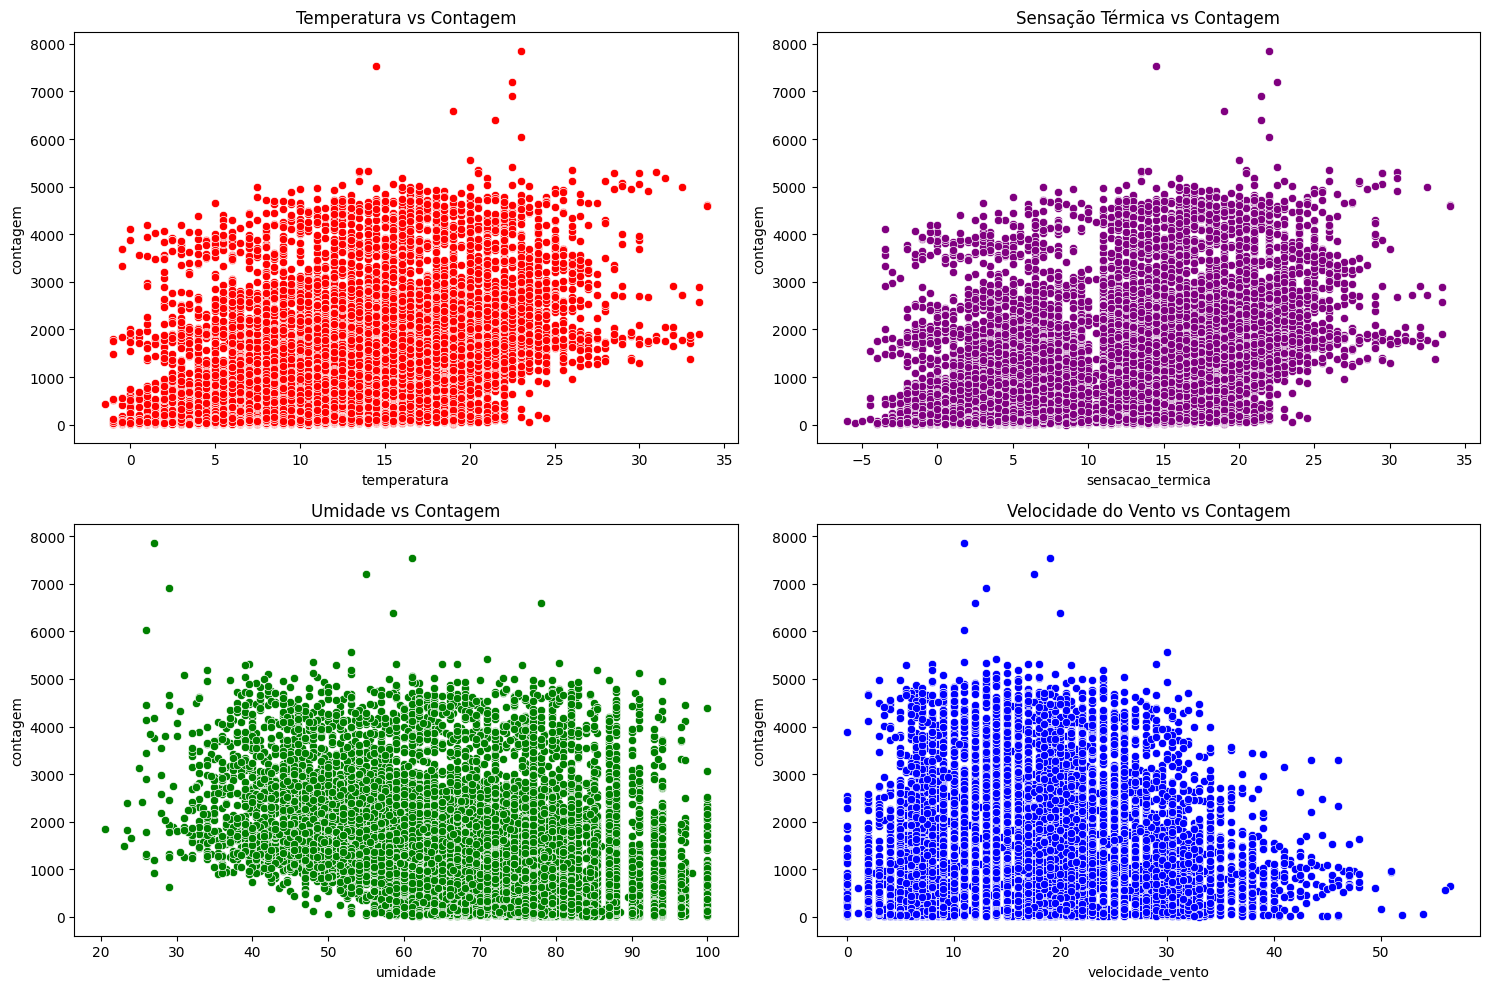

In [29]:
# prompt: crie 4 gráficos do tipo scatterplot das variáveis temperatura, sensacao_termica, umidade, velocidade_vento com a coluna contagem no eixo y. deixar os gráficos na posição 2X2. Cada gráfico deve ter um título.

# Create a figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot the scatterplots
sns.scatterplot(ax=axes[0, 0], data=df_limpo, x='temperatura', y='contagem', color='red')
axes[0, 0].set_title('Temperatura vs Contagem')
sns.scatterplot(ax=axes[0, 1], data=df_limpo, x='sensacao_termica', y='contagem', color='purple')
axes[0, 1].set_title('Sensação Térmica vs Contagem')
sns.scatterplot(ax=axes[1, 0], data=df_limpo, x='umidade', y='contagem', color='green')
axes[1, 0].set_title('Umidade vs Contagem')
sns.scatterplot(ax=axes[1, 1], data=df_limpo, x='velocidade_vento', y='contagem', color='blue')
axes[1, 1].set_title('Velocidade do Vento vs Contagem')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

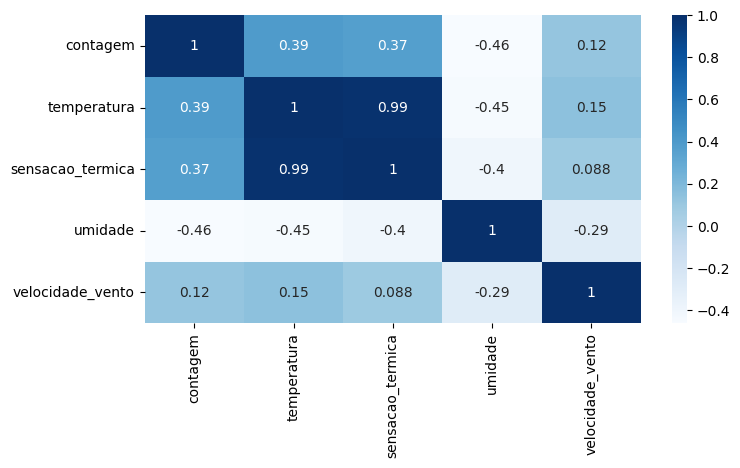

In [30]:
# Gerando um mapa de calor da correlação
plt.figure(figsize=(8,4))
sns.heatmap(df_limpo.corr(numeric_only=True), annot=True, cmap='Blues')
plt.show()

In [31]:
# estatísticas descritivas com um parâmetro específico para focar somente nas categorias
df_limpo.describe(include=[object])

,data_hora,clima,feriado,fim_de_semana,estacao
count,17414,17414,17414,17414,17414
unique,17414,6,2,2,4
top,2017-01-03 23:00:00,Céu limpo,Não,Não,Primavera
freq,1,6150,17030,12444,4394


In [32]:
# imprimir um mini relatório que liste os valores únicos de cada coluna
for col in ['clima', 'feriado', 'fim_de_semana', 'estacao']:
    print(f'Coluna: {col}')
    print(df_limpo[col].unique())
    print('='*15,'\n')

Coluna: clima
['Nublado' 'Céu limpo' 'Parcialmente nublado' 'Chuva leve' 'Neve'
 'Chuva com trovoadas']

Coluna: feriado
['Não' 'Sim']

Coluna: fim_de_semana
['Sim' 'Não']

Coluna: estacao
['Inverno' 'Primavera' 'Verão' 'Outono']



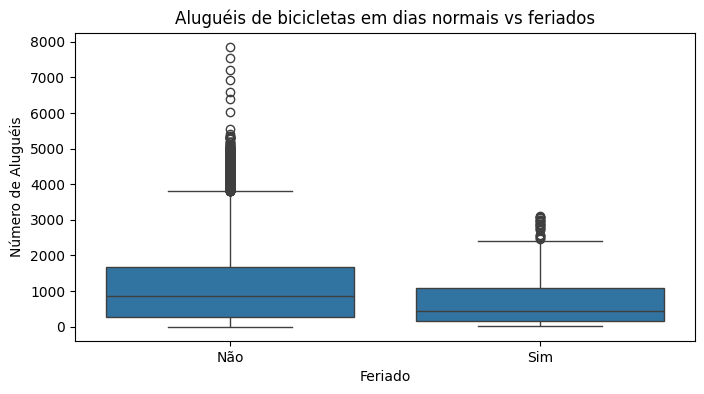

In [33]:
# Comparando dias normais, feriados e finais de semana
plt.figure(figsize=(8, 4))
sns.boxplot(x='feriado', y='contagem', order=['Não', 'Sim'], data=df_limpo)
plt.title('Aluguéis de bicicletas em dias normais vs feriados')
plt.xlabel('Feriado')
plt.ylabel('Número de Aluguéis')
plt.show()

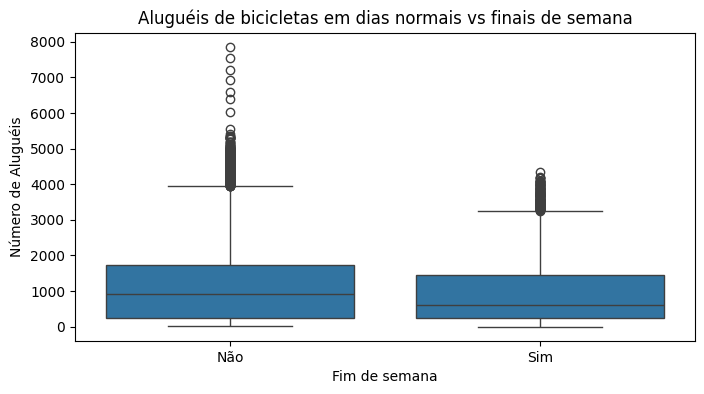

In [34]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='fim_de_semana', y='contagem', order=['Não', 'Sim'], data=df_limpo)
plt.title('Aluguéis de bicicletas em dias normais vs finais de semana')
plt.xlabel('Fim de semana')
plt.ylabel('Número de Aluguéis')
plt.show()

In [35]:
# Calculando a mediana de bicicletas alugadas para cada condição em feriado e fim_de_semana
mediana_feriado = df_limpo.groupby('feriado')['contagem'].median()
mediana_fim_de_semana = df_limpo.groupby('fim_de_semana')['contagem'].median()

In [36]:
mediana_feriado

,contagem
feriado,
Não,855.0
Sim,439.5


In [37]:
mediana_fim_de_semana

,contagem
fim_de_semana,
Não,927.0
Sim,619.0


In [38]:
# Entendemos que existe um padrão de comportamento dos clientes associado ao
# uso das bicicletas, que é mais frequente em dias normais.

In [39]:
# Investigando como o clima afeta a demanda
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index().sort_values(
    by='contagem', ascending=False)
df_clima

,clima,contagem
2,Céu limpo,7146847
5,Parcialmente nublado,6965558
4,Nublado,4243887
1,Chuva leve,1526461
3,Neve,15051
0,Chuva com trovoadas,8168


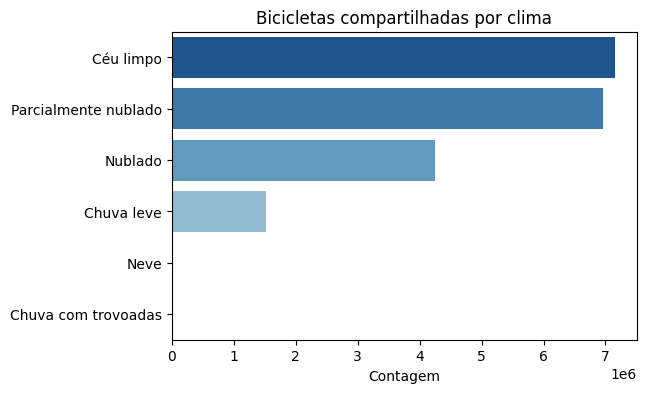

In [40]:
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index().sort_values(by='contagem', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=df_clima, y='clima', x='contagem', hue='clima', palette='Blues_r', orient='h')
plt.title('Bicicletas compartilhadas por clima')
plt.xlabel('Contagem')
plt.ylabel('')
plt.show()

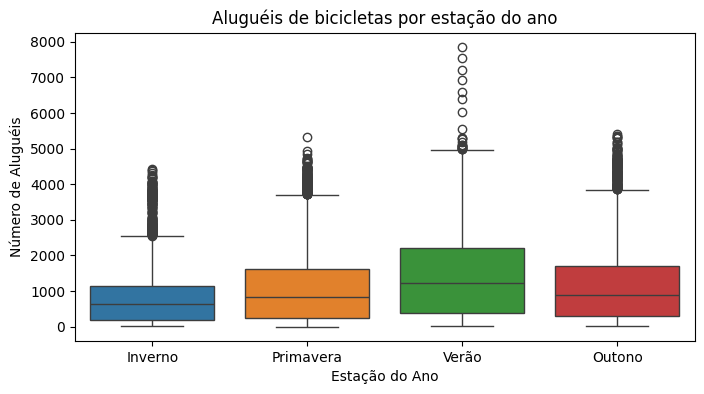

In [41]:
# Analisando as distribuições por estação
plt.figure(figsize=(8, 4))

paleta_cores = {'Primavera': 'green', 'Verão': 'orange',
                'Outono': 'brown', 'Inverno': 'blue'}
sns.boxplot(x='estacao', y='contagem', data=df_limpo, hue='estacao', )
plt.title('Aluguéis de bicicletas por estação do ano')
plt.xlabel('Estação do Ano')
plt.ylabel('Número de Aluguéis')
plt.show()

In [42]:
df_limpo.groupby('estacao')['contagem'].median()

,contagem
estacao,
Inverno,632.0
Outono,898.0
Primavera,823.0
Verão,1214.0


In [43]:
# vamos usar algum teste estatístico para comparar primavera e outono,
# para verificar se elas realmente são diferentes estatisticamente falando
# Vamos aplicar o teste Mann-Whitney, um teste não paramétrico para amostras independentes
# A hipótese nula é que a distribuição nas duas estações são iguais
# e a hipótese alternativa é que as distribuições são diferentes
from scipy.stats import mannwhitneyu

In [44]:
primavera = df_limpo[df_limpo['estacao'] == 'Primavera']['contagem']
outono = df_limpo[df_limpo['estacao'] == 'Outono']['contagem']

u_statistic, p_value = mannwhitneyu(primavera, outono, alternative='two-sided')
u_statistic, p_value

(np.float64(9044682.5), np.float64(0.0004762100221646296))

In [45]:
# como p_valor < 0.05, que é a significância para um IC de 95%, a hipótese
# nula é descartada, ou seja, as distribuições são diferentes!

In [46]:
# Convertendo o tipo do dado "data e hora"
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17414 non-null  object 
 1   contagem          17414 non-null  int64  
 2   temperatura       17414 non-null  float64
 3   sensacao_termica  17414 non-null  float64
 4   umidade           17414 non-null  float64
 5   velocidade_vento  17414 non-null  float64
 6   clima             17414 non-null  object 
 7   feriado           17414 non-null  object 
 8   fim_de_semana     17414 non-null  object 
 9   estacao           17414 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 2.0+ MB


In [47]:
df_data = df_limpo.copy()

# Convertendo a coluna data_hora para o formato datetime:
df_data['data_hora'] = pd.to_datetime(df_data['data_hora'])

df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [48]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   data_hora         17414 non-null  datetime64[ns]
 1   contagem          17414 non-null  int64         
 2   temperatura       17414 non-null  float64       
 3   sensacao_termica  17414 non-null  float64       
 4   umidade           17414 non-null  float64       
 5   velocidade_vento  17414 non-null  float64       
 6   clima             17414 non-null  object        
 7   feriado           17414 non-null  object        
 8   fim_de_semana     17414 non-null  object        
 9   estacao           17414 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 2.0+ MB


In [49]:
# Extraindo mês e hora para colunas separadas
# Criando novas colunas: mes e horario

df_data['mes'] = df_data['data_hora'].dt.month
df_data['horario'] = df_data['data_hora'].dt.hour
df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [50]:
# Retirando o horário da coluna data_hora

df_data['data_hora'] = df_data['data_hora'].dt.date

df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [51]:
# Renomeando a coluna data_hora para data:

df_data = df_data.rename(columns={'data_hora': 'data'})

df_data.head()

,data,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [52]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data              17414 non-null  object 
 1   contagem          17414 non-null  int64  
 2   temperatura       17414 non-null  float64
 3   sensacao_termica  17414 non-null  float64
 4   umidade           17414 non-null  float64
 5   velocidade_vento  17414 non-null  float64
 6   clima             17414 non-null  object 
 7   feriado           17414 non-null  object 
 8   fim_de_semana     17414 non-null  object 
 9   estacao           17414 non-null  object 
 10  mes               17414 non-null  int32  
 11  horario           17414 non-null  int32  
dtypes: float64(4), int32(2), int64(1), object(5)
memory usage: 2.1+ MB


In [53]:
# Convertendo a coluna data para o formato datetime novamente:

df_data['data'] = pd.to_datetime(df_data['data'])

In [54]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   data              17414 non-null  datetime64[ns]
 1   contagem          17414 non-null  int64         
 2   temperatura       17414 non-null  float64       
 3   sensacao_termica  17414 non-null  float64       
 4   umidade           17414 non-null  float64       
 5   velocidade_vento  17414 non-null  float64       
 6   clima             17414 non-null  object        
 7   feriado           17414 non-null  object        
 8   fim_de_semana     17414 non-null  object        
 9   estacao           17414 non-null  object        
 10  mes               17414 non-null  int32         
 11  horario           17414 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(2), int64(1), object(4)
memory usage: 2.1+ MB


In [56]:
# Agrupando por horário e somando a contagem de bicicletas
df_por_hora = df_data.groupby('horario')['contagem'].sum().reset_index()
df_por_hora

,horario,contagem
0,0,210401
1,1,145257
2,2,98275
3,3,67951
4,4,52859
5,5,79820
6,6,338771
7,7,1066309
8,8,2087164
9,9,1201745


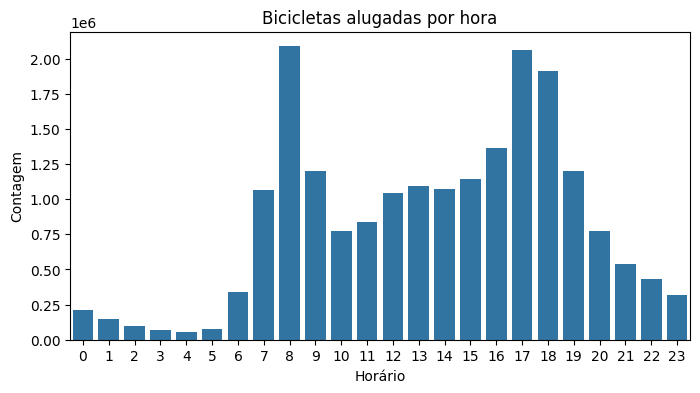

In [57]:
# Gráfico de Bicicletas alugadas por hora
plt.figure(figsize=(8,4))
sns.barplot(data=df_por_hora, x='horario', y='contagem')
plt.title('Bicicletas alugadas por hora')
plt.xlabel('Horário')
plt.ylabel('Contagem')

plt.show()

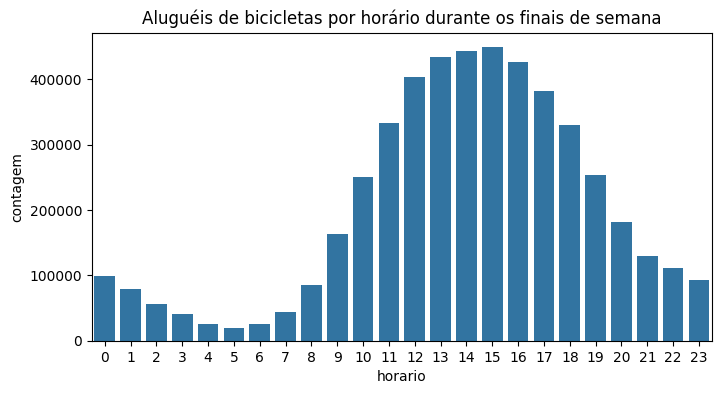

In [59]:
# Gráfico de Bicicletas alugadas por hora no fim de semana
df_fim_de_semana = df_data[df_data['fim_de_semana'] == 'Sim']
alugueis_fim_de_semana = df_fim_de_semana.groupby('horario')['contagem'].sum().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(x='horario', y='contagem', data=alugueis_fim_de_semana)
plt.title('Aluguéis de bicicletas por horário durante os finais de semana')
plt.show()

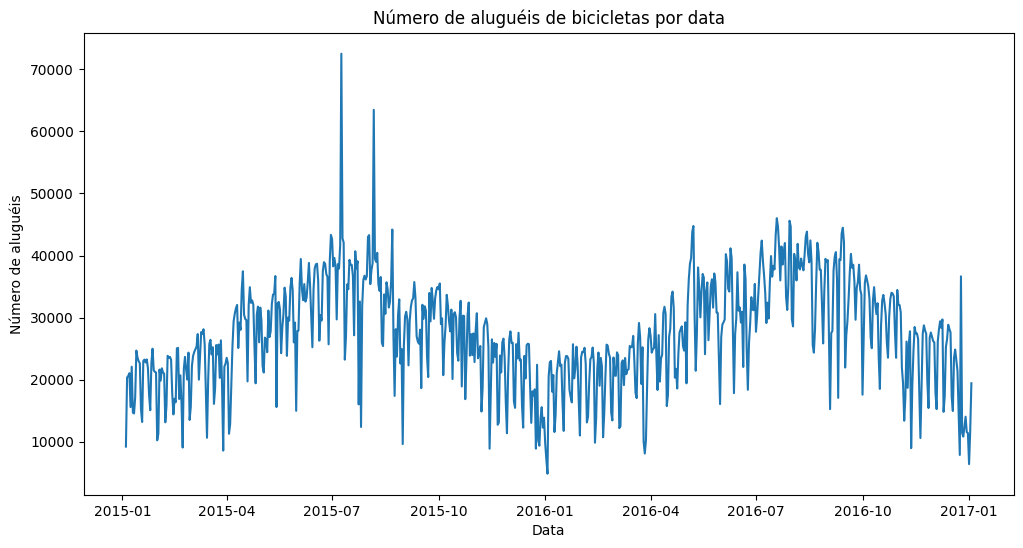

In [60]:
# Gráfico de linhas: Bicicletas alugadas por dia
df_tempo = df_data.groupby('data')['contagem'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=df_tempo, x='data', y='contagem')
plt.title('Número de aluguéis de bicicletas por data')
plt.xlabel('Data')
plt.ylabel('Número de aluguéis')
plt.show()

In [61]:
# Quando trabalhamos com uma série temporal e a analisamos, é essencial
# pensar no que aconteceu para os dados se comportarem da forma que se
# comportam, e buscar informações externas para levar em consideração na análise.

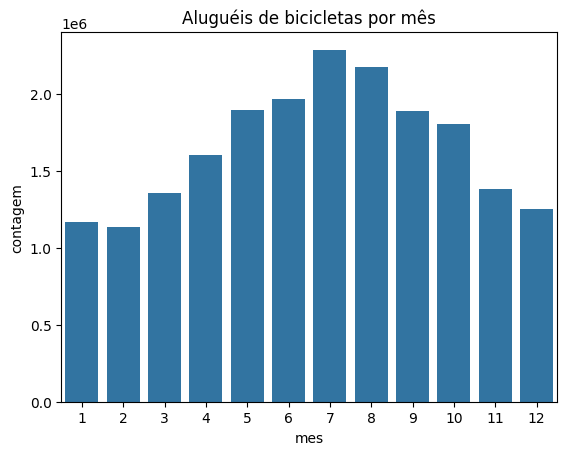

In [62]:
# Gráfico de barras: bicicletas alugadas por mês
alugueis_mensais = df_data.groupby('mes')['contagem'].sum().reset_index()

sns.barplot(data=alugueis_mensais, x='mes', y='contagem')
plt.title('Aluguéis de bicicletas por mês')
plt.show()

In [64]:
# como vimos no gráfico de linhas, há um padrão que se repete de um ano para o outro.
# Esse tipo de padrão se chama sazonalidade!

In [67]:
df_tempo = df_data.groupby('data')['contagem'].sum().reset_index()
df_tempo['mes'] = df_tempo['data'].dt.to_period('M')
df_tempo

,data,contagem,mes
0,2015-01-04,9234,2015-01
1,2015-01-05,20372,2015-01
2,2015-01-06,20613,2015-01
3,2015-01-07,21064,2015-01
4,2015-01-08,15601,2015-01
...,...,...,...
725,2016-12-30,11566,2016-12
726,2016-12-31,11424,2016-12
727,2017-01-01,6421,2017-01
728,2017-01-02,11823,2017-01


In [68]:
media_aluguel_mes = df_tempo.groupby(['mes'])['contagem'].mean().reset_index()
media_aluguel_mes

,mes,contagem
0,2015-01,19522.821429
1,2015-02,19414.071429
2,2015-03,22449.483871
3,2015-04,27719.400000
4,2015-05,28884.290323
5,2015-06,34441.733333
6,2015-07,36151.193548
7,2015-08,33353.258065
8,2015-09,29749.266667
9,2015-10,27904.709677


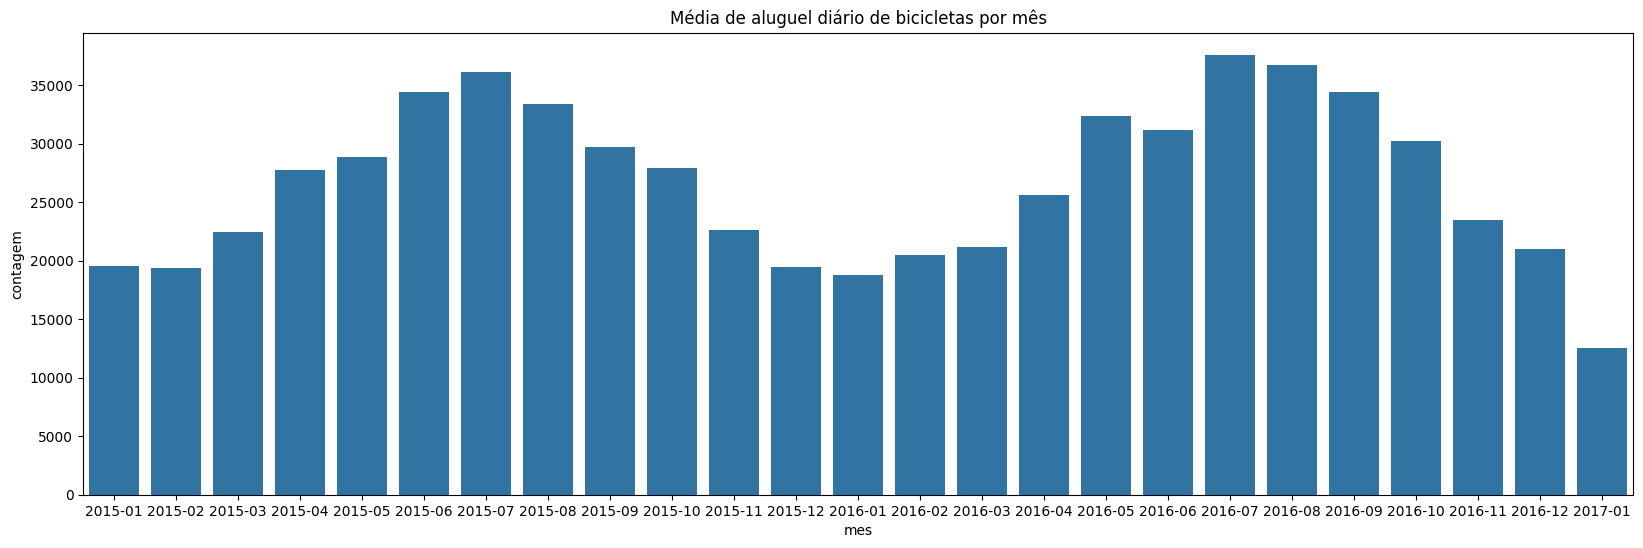

In [69]:
plt.figure(figsize = (20,6))
sns.barplot(x='mes', y='contagem', data=media_aluguel_mes)
plt.title('Média de aluguel diário de bicicletas por mês')
plt.show()

In [70]:
# utilizando a biblioteca Prophet para fazer previsões
from prophet import Prophet

In [71]:
# criando nosso dataframe
df_prophet = df_data[['data', 'contagem']].rename(columns={'data': 'ds', 'contagem': 'y'})
df_prophet.head()

,ds,y
0,2015-01-04,182
1,2015-01-04,138
2,2015-01-04,134
3,2015-01-04,72
4,2015-01-04,47


In [73]:
# agrupando os dias
df_prophet = df_prophet.groupby('ds')['y'].sum().reset_index()
df_prophet

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [74]:
# Definindo um seed para garantir a reprodutibilidade
import numpy as np
np.random.seed(4587) # pode ser qualquer número inteiro e positivo

In [75]:
# Instanciando o modelo Prophet
modelo = Prophet()

# Treinando o modelo
modelo.fit(df_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [77]:
# criando um dataframe com as datas que queremos prever (90 dias)
futuro = modelo.make_future_dataframe(periods=90, freq='D')

In [78]:
#Realizando a previsão
previsao = modelo.predict(futuro)

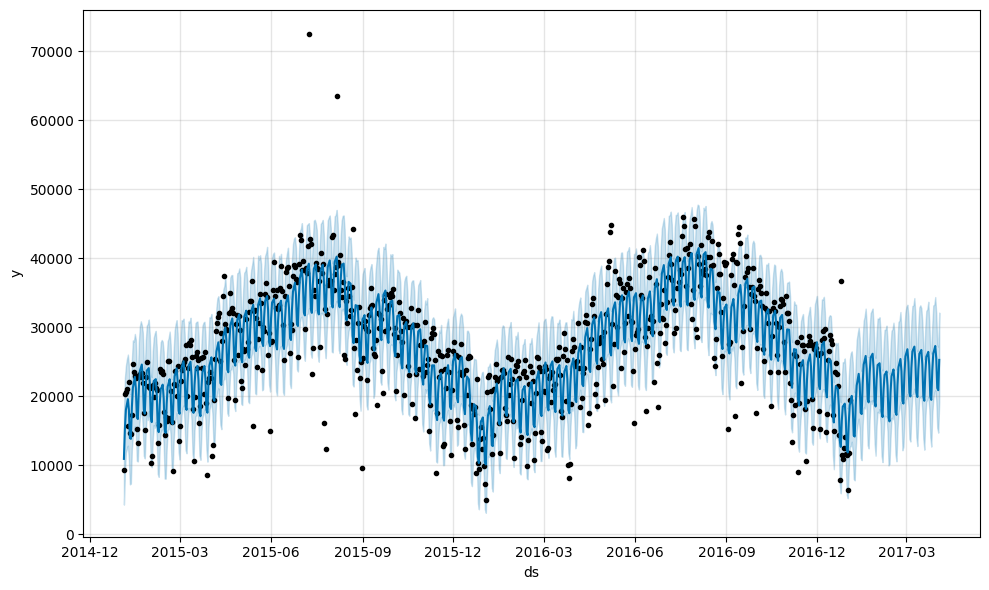

In [79]:
# visualizando os resultados
fig1 = modelo.plot(previsao)

In [ ]:
# A linha azul escura é a nossa previsão, os valores que o Prophet está prevendo.
# Os pontos pretos são os valores reais de y, os valores do dataframe para cada dia.
# A faixa azul mais clara é o intervalo de confiança.
# É importante que os pontos pretos, nossos valores reais de y, estejam dentro
# do intervalo de confiança.
# O período sem pontos pretos equivale ao da nossa previsão (de 90 dias)
# São novos valores previstos pelo modelo com base nos dados anteriores.

In [80]:
# Explorando os valores previstos
previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2015-01-04,10901.154244,4272.997136,17164.508752
1,2015-01-05,15311.240748,8913.294368,22636.591868
2,2015-01-06,18014.358032,11829.948757,24414.209755
3,2015-01-07,18744.724106,12344.157939,25364.890690
4,2015-01-08,19556.198950,12809.818276,26023.647584
...,...,...,...,...
815,2017-03-30,27262.728299,20840.904012,34360.830591
816,2017-03-31,25490.739772,19305.494930,31997.944446
817,2017-04-01,21173.735187,15400.561433,27665.218437
818,2017-04-02,20856.723857,14700.899883,27176.715100


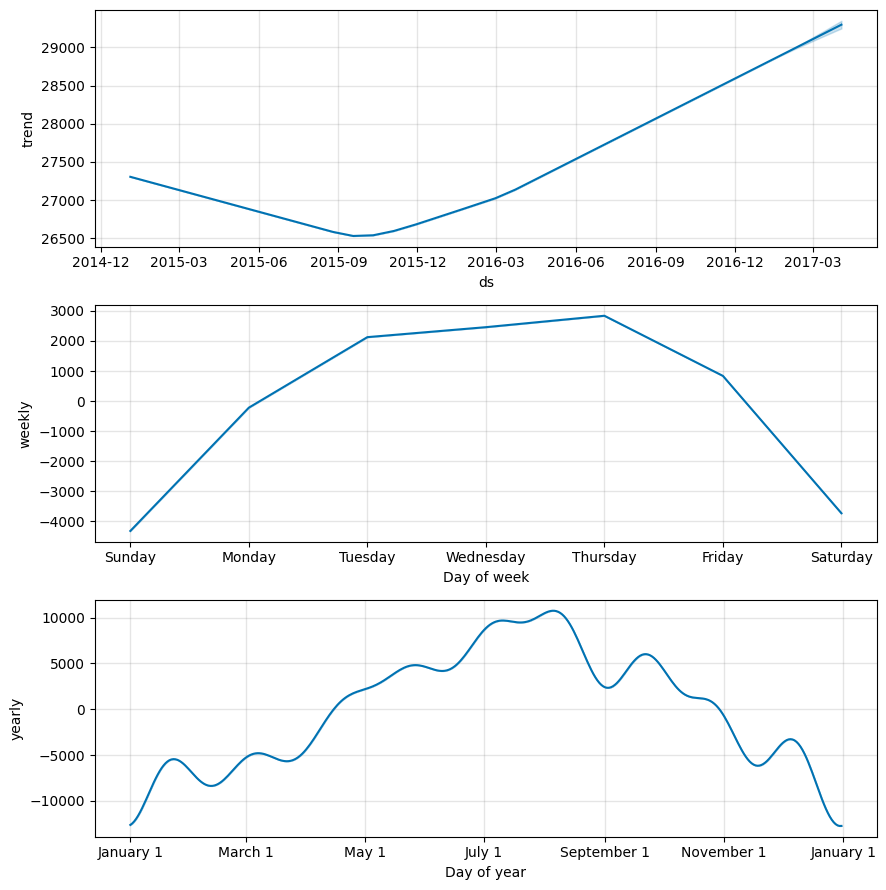

In [81]:
fig2 = modelo.plot_components(previsao)

In [82]:
# Cada gráfico representa um componente diferente que o Prophet utilizou para fazer a previsão.
# O primeiro componente é a tendência. Ele indica se a previsão está aumentando ou diminuindo.
# Os outros dois são componentes relacionados à sazonalidade (semanal e anual)

In [83]:
# Separando os dados em treino e teste
df_prophet.shape

(730, 2)

In [84]:
df_treino = pd.DataFrame()

# Separando 80% dos dados para treino
df_treino['ds'] = df_prophet['ds'][:584]
df_treino['y'] = df_prophet['y'][:584]

In [85]:
df_teste = pd.DataFrame()

# Separando 20% dos dados para teste
df_teste['ds'] = df_prophet['ds'][584:]
df_teste['y'] = df_prophet['y'][584:]

In [88]:
# Treinamento do modelo com dados de treino
np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_treino)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [89]:
# Previsão dos dados futuros
futuro = modelo.make_future_dataframe(periods=150, freq='D')
previsao = modelo.predict(futuro)

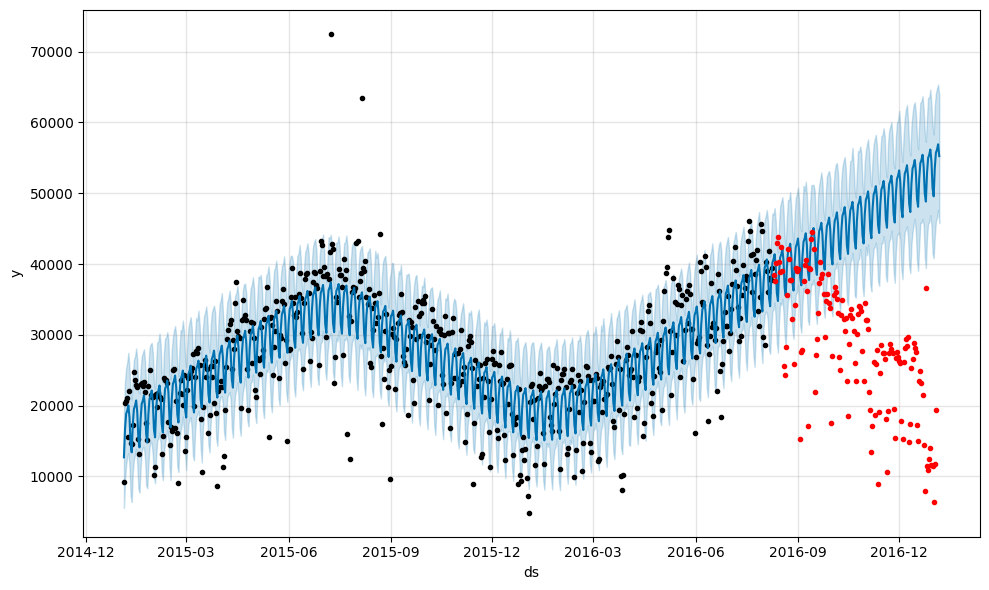

In [90]:
# Visualização da previsão e dos dados de teste
fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

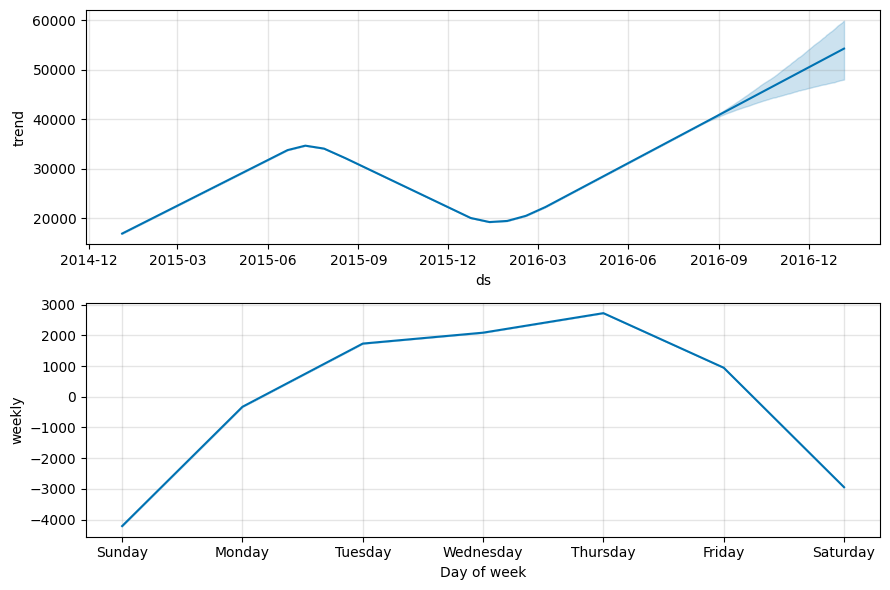

In [91]:
fig2 = modelo.plot_components(previsao)

In [92]:
# notamos que a sazonalidade anual não está sendo considerada, apenas a
# sazonalidade semanal. Isso ocorreu porque, quando rodamos o modelo, ele
# desabilitou a sazonalidade anual, conforme indicado na primeira linha da saída do modelo.
# Essa desativação da sazonalidade anual resultou em uma previsão inadequada.

In [94]:
# DataFrame de comparação
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,40646.668345,38430
1,2016-08-11,41387.556531,37626
2,2016-08-12,39717.738075,40159
3,2016-08-13,35936.818948,43041
4,2016-08-14,34777.781620,43848
...,...,...,...
141,2016-12-30,54505.507535,11566
142,2016-12-31,50724.588409,11424
143,2017-01-01,49565.551080,6421
144,2017-01-02,53551.527936,11823


In [95]:
# Quantificação dos erros
# o Erro Quadrático Médio (MSE), que nos dá uma noção clara de
# quanto o modelo está errando em média.
# Para obter um valor mais compreensível, tiramos a raiz quadrada do MSE,
# resultando na métrica Raiz do Erro Quadrático Médio (RMSE).

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f'MSE:{mse}, RMSE:{rmse}')


MSE:466131885.83721644, RMSE:21590.087675533337


In [96]:
# Isso significa que nosso modelo está errando, em média, 21.590 bicicletas por dia,
# o que é um erro bastante significativo.

In [97]:
# copiamos como criamos o modelo, mas habilitamos a sazonalidade anual
np.random.seed(4587)

modelo = Prophet(yearly_seasonality=True)
modelo.fit(df_treino)
futuro = modelo.make_future_dataframe(periods=150, freq='D')
previsao = modelo.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


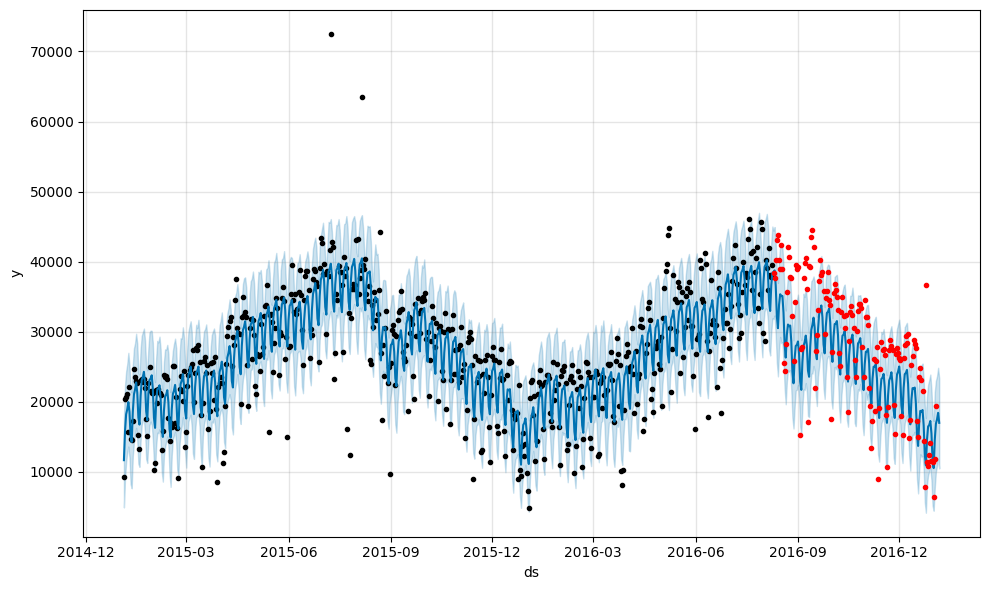

In [98]:
fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

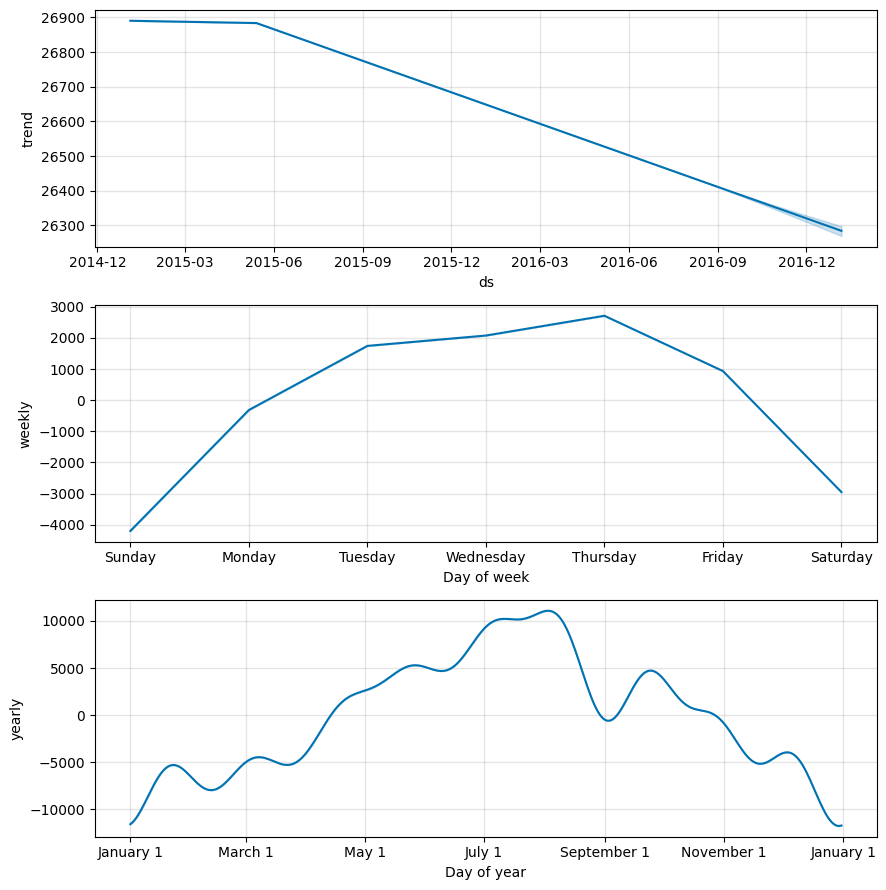

In [106]:
# temos os dados de teste mais encaixados dentro do intervalo de confiança
fig2 = modelo.plot_components(previsao)

In [107]:
# verificando o RMSE
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,38465.384263,38430
1,2016-08-11,38747.176173,37626
2,2016-08-12,36570.409008,40159
3,2016-08-13,32236.956009,43041
4,2016-08-14,30495.343635,43848
...,...,...,...
141,2016-12-30,15472.667459,11566
142,2016-12-31,11648.768320,11424
143,2017-01-01,10517.621774,6421
144,2017-01-02,14572.990084,11823


In [108]:
mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f'MSE:{mse}, RMSE:{rmse}')

MSE:38623874.116090804, RMSE:6214.810867282351


In [109]:
# o RMSE caiu de 21.000 bicicletas para 6.214, exibindo uma grande melhora

In [110]:
# Vamos remover os valores que estão fora do intervalo de confiança,
# para ver se melhoramos o modelo mais ainda
df_prophet

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [111]:
# Vamos fazer uma previsão bem simples para obter os intervalos de confiança e
# fazer essa remoção
np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_prophet)
futuro = modelo.make_future_dataframe(periods=0)
previsao = modelo.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [112]:
# A ideia vai ser filtrar os valores em que o y seja maior que aquele yhat_lower
# da previsão e menor que o yhat_upper da previsão

sem_outliers = df_prophet[(df_prophet['y'] > previsao['yhat_lower'])
& (df_prophet['y'] < previsao['yhat_upper'])]

In [114]:
# Criando o dataframe de treino
df_treino = pd.DataFrame()

df_treino['ds'] = sem_outliers['ds'][:505] # 80% da base
df_treino['y'] = sem_outliers['y'][:505]

In [115]:
# Criando o dataframe de teste
df_teste = pd.DataFrame()

df_teste['ds'] = sem_outliers['ds'][505:]
df_teste['y'] = sem_outliers['y'][505:]

In [116]:
# Melhorando o Modelo de Previsão
np.random.seed(4587)

modelo_sem_outliers = Prophet(yearly_seasonality=True)
modelo_sem_outliers.fit(df_treino)
futuro = modelo_sem_outliers.make_future_dataframe(periods=365, freq='D')
previsao = modelo_sem_outliers.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


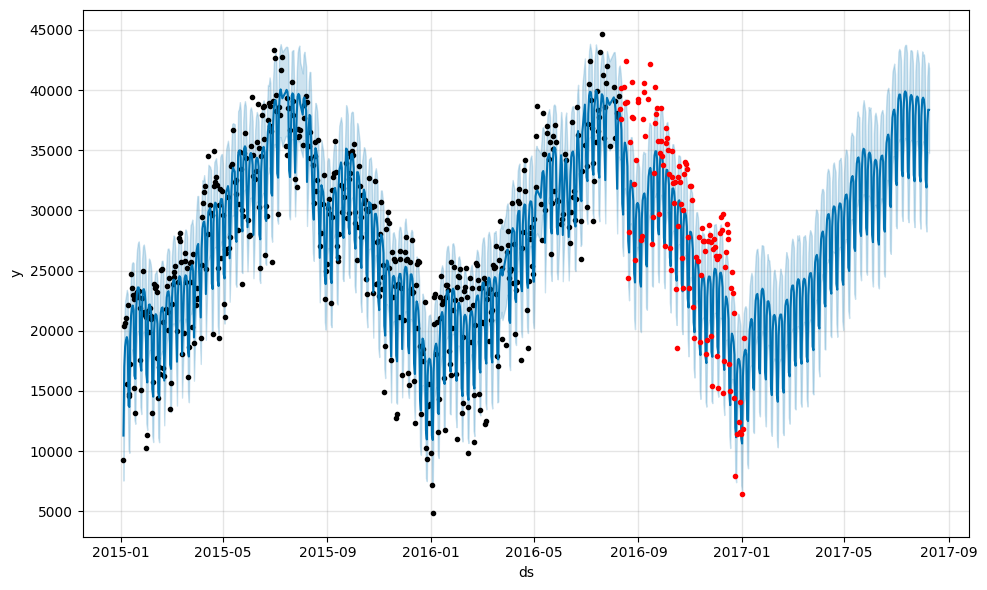

In [117]:
fig1 = modelo_sem_outliers.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

In [118]:
# Há valores que não entraram na previsão, mas a quantidade é bem menor
# que anteriormente.

In [119]:
# verificando o RMSE
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,38124.198030,38430
1,2016-08-11,37708.698302,37626
2,2016-08-12,36664.037121,40159
3,2016-08-15,34692.044716,40236
4,2016-08-16,35633.104939,38911
...,...,...,...
121,2016-12-30,16752.032190,11566
122,2016-12-31,11045.349857,11424
123,2017-01-01,10626.465284,6421
124,2017-01-02,16230.478647,11823


In [120]:
mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f'MSE: {mse}, RMSE: {rmse}')

MSE: 15673011.905989861, RMSE: 3958.91549619209


In [121]:
# Estávamos com cerca de 6 mil de valor de erro antes de tratar os outliers,
# portanto, conseguimos diminuir bastante o erro. O resultado atual ficou
# bem melhor do que o anterior.

In [122]:
# Aumentando o período da previsão
np.random.seed(4587)

modelo_sem_outliers = Prophet(yearly_seasonality=True)
modelo_sem_outliers.fit(df_treino)
futuro = modelo_sem_outliers.make_future_dataframe(periods=365, freq='D')
previsao = modelo_sem_outliers.predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [123]:
# Analisando dados dinamicamente
from prophet.plot import plot_plotly
fig = plot_plotly(modelo_sem_outliers, previsao)
fig.show()